In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov
import matplotlib.pyplot as pl
%matplotlib inline






/tmp/ipykernel_4193908/3187127388.py:10: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


In [3]:
# def get_samps(fname, acorr_max = 0.075, acorr_min = 0.0075):
#     df = pk.load(open(fname,'rb'))
#     sig8 = df['sigma8']
#     nchains = 64
#     sig8_rs = sig8.reshape(nchains,-1)
#     # print(sig8_rs.shape)
#     from numpyro.diagnostics import autocorrelation, autocovariance
    
#     acorr = autocorrelation(sig8_rs, axis=1)
#     ind_del = []
#     for ji in range(acorr.shape[0]):
#         if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
#             ind_del.append(ji)    
#     print(len(ind_del))
#     samps = []
#     keys = []
#     for key in df:
#         if ('base' not in key) and ('decentered' not in key):
#             if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
#             # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
#                 if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
#                     for jb in range(4):
#                         samps.append(df[key][:, jb])
#                         keys.append(key + '_' + str(jb))
#                         # print(df[key][:, jb].shape)
#                 # print(samps[0].shape)
#                 # print(df[key].shape)
#                 else:
#                     samps.append(df[key])
#                     keys.append(key)
    
#     samps = np.array(samps).T
#     ind_sigma8 = keys.index('sigma8')
#     # ind_thetaejM = keys.index('nu_theta_ej_M')
#     ind_Om = keys.index('Om0')
#     samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
#     samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
#     keys.append('S8')
    
#     import getdist
#     from getdist import plots, MCSamples
    
#     names = keys    
#     ind_frac_rm = 0.5
#     # nchains = 80
#     samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
#     nsamp_per_chain = samps_sel.shape[1]
#     nrm = int(ind_frac_rm * nsamp_per_chain)
#     samps_sel = samps_sel[:, nrm:, :]
    
#     if len(ind_del) > 0:
#         samps_sel = np.delete(samps_sel, ind_del, axis=0)
#     else:
#         samps_sel = samps_sel
    
#     samps = samps_sel.reshape(-1, samps_sel.shape[-1])
#     print(samps.shape, samps_sel.shape)
#     return samps, keys

# # ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/'
# # samps, keys = get_samps(ldir + 'mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')

# ldir = abs_path_results + '/DESxACT/chains_Feb/'
# # probe = 'xip_xim'
# probe = 'all'
# # samps, keys = get_samps(ldir + 'mcmc_v10_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps, keys = get_samps(ldir + f'mcmc_v13_maskPS_probe_{probe}_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# # samps, keys = get_samps(ldir + f'mcmc_v11_nzfix_probe_{probe}_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')

# nsamp_tot = samps.shape[0]
# np.random.seed(42)
# # indsel = np.sort(np.random.randint(0, nsamp_tot, 128))


# indsel = np.unique(np.sort(np.random.randint(0, nsamp_tot, 1024)))

# # indsel = np.sort(np.random.randint(0, nsamp_tot, 8))
# # indsel = np.sort(np.random.randint(0, nsamp_tot, 512))






12
(208000, 22) (52, 4000, 22)


In [2]:
import numpy as np
from astropy import constants as const
from astropy import units as u

def get_Tcmb_K():
    Tcmb = 2.7255
    return Tcmb

def tsz_freq(nu):
    #Input frequency in GHz, output conversion from y to \Delta T/T_CMB
    #nu in GHz
    #See carlstrom paper: https://ned.ipac.caltech.edu/level5/Sept05/Carlstrom/Carlstrom2.html
    T_cmb = get_Tcmb_K()*u.K
    x = (const.h*nu*(1.0e9*1./u.s)/(const.k_B*T_cmb)).to('').value
    f_x = x*((np.exp(x) + 1.)/(np.exp(x) - 1.)) - 4.
    return f_x

fac = (1e-12)/(((get_Tcmb_K())*tsz_freq(150))**2)

fnameDl_yy_planck = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/bolliet_18_cl_yy_mean.txt')
ell = fnameDl_yy_planck[:,0]
Dl_yy_planck = fnameDl_yy_planck[:,1] * 1e-12

fnameDl_yy_planck = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/bolliet_18_cl_yy_meanp1sig.txt')
err_Dlyy_planck = (fnameDl_yy_planck[:,1] * 1e-12 - Dl_yy_planck)


act_Dl_ratio = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/ACT_DR6_Dlyy_ratio_3000.txt')
ell_act_Dl_ratio = act_Dl_ratio[:,0]
Dl_ratio_act = act_Dl_ratio[:,1]

# fac = (1e-12)/(((get_Tcmb_K())*tsz_freq(150))**2)


In [31]:
from tqdm import tqdm
from godmax.base_class import get_vmapped_func, get_vmapped_func_warg, EmptyCallable
from jax import jit, vmap
import interpax
import jax.scipy.integrate as jsi
from tqdm import tqdm
from colossus.cosmology import cosmology as cosmology_colossus
from colossus.halo import mass_defs
from colossus.halo import concentration
from scipy.interpolate import interp1d




# ind_post = keys.index('potential_energy')
# post = -1.* samps[:,ind_post]

# map_ind = np.where(post == post.max())[0][0]

# Y_model_all_samp = []
# Cl_yy_all_samp = []

# for map_ind in tqdm(indsel):
# for map_ind in tqdm(indsel[0:128]):   
# for map_ind in [89042]: ####***********######
# for map_ind in [26641]:
# for map_ind in [64820]:
saved_bestfit = {}
for jk, key in enumerate(keys):
    # print(key, samps[map_ind, jk])
    saved_bestfit[key] = samps[map_ind, jk]

# potential_energy -4916.635080802822
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
new_data = read_yaml(abs_path_params + '/Pge/params.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)


# saved_bestift
from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])


analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)

analysis_dict['beam_fwhm_arcmin'] = 1.6
analysis_dict['beam_fwhm_arcmin'] = 1.6

# for key in saved_bestfit.keys():
#     if key in list(sim_params_dict.keys()):
#         sim_params_dict[key] = float(saved_bestfit[key])
#     if key in list(sim_params_dict['cosmo'].keys()):
#         sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
#         if key == 'h':
#             sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
#     if key in list(other_params_dict.keys()):
#         other_params_dict[key] = float(saved_bestfit[key])
# for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
#     other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
# for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
#     other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']


# sim_params_dict['cosmo']['Om0'] = 0.3
# sim_params_dict['cosmo']['Ob0'] = 0.048
# sim_params_dict['cosmo']['sigma8'] = 0.80
# sim_params_dict['cosmo']['ns'] = 0.96
# sim_params_dict['theta_ej_0'] = 2.0
# sim_params_dict['nu_theta_ej_M'] = -0.33
# sim_params_dict['nu_theta_ej_z'] = -1.22
# halo_params_dict['rmax'] = 12.0
# halo_params_dict['nr'] = 128
# halo_params_dict['nk'] = 96
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
vmapped_func = get_vmapped_func_warg(Pkz_test.get_P_1h, 2, 4)
Pyy_1h_kz_mat = vmapped_func(jnp.arange(Pkz_test.nk), jnp.arange(Pkz_test.nz), 3, 3).T
Pyy_2h_kz_mat = Pkz_test.by_kz_mat * Pkz_test.by_kz_mat * Pkz_test.plin_kz_mat
Pyy_tot_mat = Pyy_1h_kz_mat + Pyy_2h_kz_mat

print(profiles_test.fstar_tot_mat[10,:])
# Bl_array = jnp.exp(-1. * Pkz_test.ell_array * (Pkz_test.ell_array + 1) * (Pkz_test.sig_beam ** 2) / 2.)
# Bl_mat = Bl_array[:, None]

@jit
def get_P_lz(jl, jz, Pk_mat):
    ell = base_test.ell_array[jl]
    chi_z = base_test.chi_array[jz]
    k_ell = (ell + 0.5)/jnp.clip(chi_z, 1.0)
    Pkz_ell = jnp.exp(jnp.interp(jnp.log(k_ell), jnp.log(base_test.kPk_array), jnp.log(Pk_mat[:,jz])))
    return Pkz_ell

vmapped_func = get_vmapped_func_warg(get_P_lz, 2, 3)
Pkyy_lz_mat = vmapped_func(jnp.arange(base_test.nell), jnp.arange(base_test.nz), Pyy_tot_mat).T

# Pkyy_lz_mat = Pkyy_lz_mat * (Bl_mat**2)
logPkyylz_2d_interp = interpax.Interpolator2D(jnp.log(base_test.ell_array), base_test.z_array, jnp.log(Pkyy_lz_mat), extrap=True)        

@jit
def get_Cl_tot(jl):
    Pk = jnp.exp(logPkyylz_2d_interp(jnp.log(base_test.ell_array[jl]), base_test.z_array_for_Cls))
    Wy_array = (1.0 / (1.0 + base_test.z_array_for_Cls))

    prefac = Wy_array / (base_test.chi_array_for_Cls**2)
    fx = prefac * prefac  * (base_test.chi_array_for_Cls ** 2) * base_test.dchi_dz_array_for_Cls * Pk
    return jsi.trapezoid(fx, x=base_test.z_array_for_Cls)     

Cl_yy = vmap(get_Cl_tot)(jnp.arange(base_test.nell))
fach = 1e12*((base_test.ell_array)*(base_test.ell_array + 1) / (2 * np.pi))
# if np.abs((fach*Cl_yy)[np.argmin(np.abs(base_test.ell_array - 3000))] - 1e12*3.42*fac)/(1e12*3.42*fac) < 0.2:
jz_fb = 10
if True:

    cosmop = sim_params_dict['cosmo']
    params = {'w0':-1.0 ,'flat': True, 'H0': cosmop['H0'], 'Om0': cosmop['Om0'], 'Ob0': cosmop['Ob0'], 'sigma8':cosmop['sigma8'] ,'ns': cosmop['ns']}
    cosmology_colossus.addCosmology('myCosmo', params)
    cosmology_colossus.setCosmology('myCosmo')
    cosmo_colossus = cosmology_colossus.setCosmology('myCosmo')
    
    h = params['H0']/100.
    z = z_array[jz_fb]
    M500c_min_wh = 6e13*h
    M500c_max_wh = 2e14*h
    c500c_min_wh = concentration.concentration(M500c_min_wh, '500c', z, model = 'bhattacharya13')
    c500c_max_wh = concentration.concentration(M500c_max_wh, '500c', z, model = 'bhattacharya13')
    M200c_min_wh, _, _ = mass_defs.changeMassDefinition(M500c_min_wh, c500c_min_wh, z, '500c', '200c')
    M200c_max_wh, _, _ = mass_defs.changeMassDefinition(M500c_max_wh, c500c_max_wh, z, '500c', '200c')
    
    halo_params_dict['lg10_Mmin'] = np.log10(M200c_min_wh)
    halo_params_dict['lg10_Mmax'] = np.log10(M200c_max_wh)
    
    halo_params_dict['zmin'] = z
    halo_params_dict['zmax'] = z + 0.01
    halo_params_dict['nz'] = 3

    halo_params_dict['nr'] = 32
    
    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    
    
    M200c_array = profiles_test.M_array
    conc_array = profiles_test.conc_Mz_mat[0,:]
    M500c_array, R500c_array, _ = mass_defs.changeMassDefinition(M200c_array, conc_array, z, '200c', '500c')
    R500c_array /= 1000.
    
    rho_baryon_mat = profiles_test.rho_gas_mat + profiles_test.rho_cga_mat + ((profiles_test.fstar_sat_mat/profiles_test.fclm_mat)[None,:,:])*profiles_test.rho_clm_mat
    rho_tot_mat = profiles_test.rho_dmb_mat
    rho_baryon_mat_z0 = rho_baryon_mat[:,0,:]
    rho_tot_mat_z0 = rho_tot_mat[:,0,:]
    
    fb_array = np.zeros(len(M500c_array))
    for jM in range(len(M500c_array)):
            r500_jM = R500c_array[jM]
            r_array_jM = np.logspace(-3, np.log10(r500_jM), 100)
            rho_baryon_jM = rho_baryon_mat_z0[:,jM]
            interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_baryon_jM), fill_value='extrapolate')
            rhob_jM = np.exp(interprho(np.log(r_array_jM)))
            rhob_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhob_jM, np.log(r_array_jM))
    
    
            rho_tot_jM = rho_tot_mat_z0[:,jM]
            interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_tot_jM), fill_value='extrapolate')
            rhotot_jM = np.exp(interprho(np.log(r_array_jM)))
            rhotot_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhotot_jM, np.log(r_array_jM))
    
            fb_array[jM] = rhob_int_jM/rhotot_int_jM
    
    fb_bar = np.trapezoid(fb_array * profiles_test.hmf_Mz_mat[0, :], x=np.log(profiles_test.M_array))/np.trapezoid(profiles_test.hmf_Mz_mat[0, :], x=np.log(profiles_test.M_array))
    fb_bar_norm = fb_bar/(cosmop['Ob0']/cosmop['Om0'])

    # fb_norm_all_samp.append(fb_bar_norm)
    

    # print(map_ind, z, fb_bar_norm, sim_params_dict)
    print(z, fb_bar_norm, sim_params_dict)


    # Cl_yy_all_samp.append(Cl_yy)
    # ratio = Pkz_test.Pmm_dmb_tot_mat[:,0]/Pkz_test.Pmm_nfw_tot_mat[:,0]    
    # Pmm_ratio_all_samp.append(savitzky_golay(ratio, 19, 3))




[1.01610835e-05 5.94351400e-05 1.26806670e-04 1.89838108e-04
 2.33508634e-04 2.70698130e-04 2.98067779e-04 3.27262431e-04
 3.61098234e-04 3.99557290e-04 4.50227258e-04 5.03943881e-04
 5.57775464e-04 5.98286425e-04 6.23934126e-04 6.21259180e-04
 6.00655680e-04 5.56994559e-04 5.03945953e-04 4.44947424e-04
 4.19326639e-04 4.78957930e-04 7.09866059e-04 1.16126002e-03]
26641 0.10500000000000001 0.12313058582987324 {'cosmo': {'flat': True, 'H0': 67.2, 'Om0': 0.3, 'Ob0': 0.048, 'sigma8': 0.8, 'ns': 0.96, 'w0': -1.0}, 'init_power': True, 'nfw_trunc': True, 'epsilon_rt': 4.0, 'theta_ej_0': 2.0, 'log10_Mstar0_theta_ej': 16.0, 'nu_theta_ej_M': -0.33, 'nu_theta_ej_z': -1.22, 'theta_co_0': 0.05, 'log10_Mstar0_theta_co': 16.0, 'nu_theta_co_M': 0.0, 'nu_theta_co_z': 0.0, 'mu_beta': 0.0762, 'log10_Mstar0': 14.0, 'log10_Mc0': 13.75, 'nu_z': 0.0, 'nu_M': 0.0, 'gamma_rhogas': 2.0, 'delta_rhogas': 7.0, 'a_zeta': 0.3, 'n_zeta': 2.0, 'alpha_nt': 0.05, 'beta_nt': 0.5, 'n_nt': 0.3, 'log10M1_fshmr': 12.55, 'lo

In [29]:
# profiles_test.z_array
# analysis_dict
# analysis_dict['k_array_survey']

profiles_test.fstar_sat_mat




Array([[3.47801011e-265, 9.77335026e-252, 5.55108013e-239,
        6.92210407e-227, 2.04962153e-215, 1.55228565e-204,
        3.22663436e-194, 1.96807809e-184, 3.75303090e-175,
        2.37617330e-166, 5.28796911e-158, 4.36609120e-150,
        1.40747849e-142, 1.85619311e-135, 1.05100778e-128,
        2.66916556e-122, 3.16909662e-116, 1.82960925e-110,
        5.33130732e-105, 8.12295294e-100, 6.69202260e-095,
        3.07729834e-090, 8.14033148e-086, 1.27464535e-081],
       [8.46352440e-258, 9.87837836e-245, 2.43880879e-232,
        1.38010463e-220, 1.93182974e-209, 7.18981779e-199,
        7.61914882e-189, 2.45325953e-179, 2.55257837e-170,
        9.09871205e-162, 1.17435889e-153, 5.78432481e-146,
        1.14247414e-138, 9.46850975e-132, 3.45107108e-125,
        5.77176855e-119, 4.61145969e-113, 1.82864589e-107,
        3.73174419e-102, 4.05602932e-097, 2.42572635e-092,
        8.23279052e-088, 1.63281222e-083, 1.94567782e-079],
       [1.10675097e-250, 5.54055017e-238, 6.12954954e-

In [27]:
# import pickle as pk
# df = pk.load(open('/Users/shivam/Downloads/Pksup_YMerr_v12_maskPS_True_plot_data_nsamps_6000_v12_all_probes.pkl','rb'))
# Pmin_all = df['Pmin']
# Pmax_all = df['Pmax']
# kPk_array = df['k_array']
# np.savetxt('/Users/shivam/Downloads/Pksup_min_max.txt', np.array([kPk_array, Pmin_all, Pmax_all]).T, header='k(h/Mpc)    Pksup_min    Pksup_max', fmt='%e')


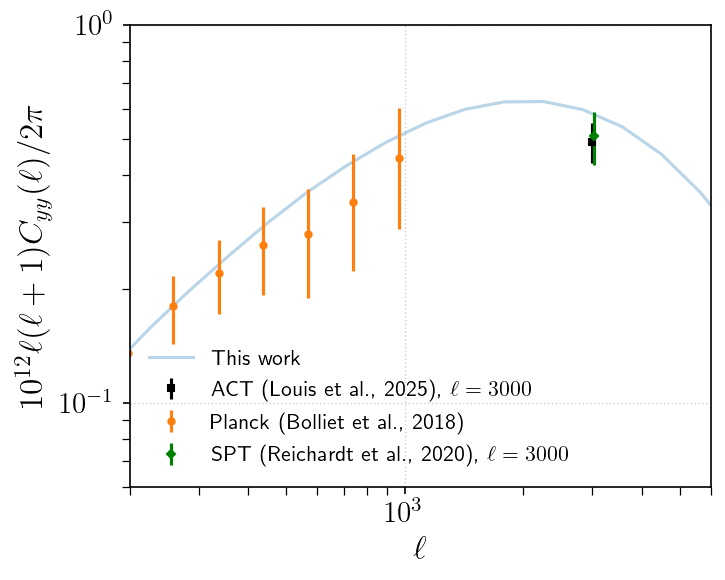

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(5, 4), dpi=150)

# Fill region with transparency
# plt.fill_between(M_array, Ymin, Ymax, alpha=0.3, color='tab:blue', label='This Work')
plt.plot(base_test.ell_array, fach*Cl_yy, color='tab:blue', alpha=0.3, label='This work')
# plt.fill_between(M_array, Ymin_2sigma, Ymax_2sigma, alpha=0.2, color='tab:blue')

# Plot main curve with improved styling
vljv,vljvp, vljvn = 3.3*fac,(3.3+0.4)*fac,(3.3-0.4)*fac
plt.errorbar(np.array([3000.]),1e12*np.array([vljv]),yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='s',ms='3',color='black',label=r'ACT (Louis et al., 2025), $\ell=3000$')
# plt.plot(ell_act_Dl_ratio, 1e12*Dl_ratio_act*3.3*fac, ls='--', color='black', label='ACT (Louis et al., 2025) bestfit')
plt.errorbar(ell, 1e12*Dl_yy_planck, yerr=1e12*err_Dlyy_planck, ls='', marker='o', ms='3', color='tab:orange', label='Planck (Bolliet et al., 2018)')
vljv,vljvp, vljvn = 3.42*fac,(3.42+0.54)*fac,(3.42-0.54)*fac
plt.errorbar([3024],[1e12*vljv],yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='D',ms='3',color='green',label=r'SPT (Reichardt et al., 2020), $\ell=3000$')



# Log scales for better visualization
plt.xscale('log')
plt.yscale('log')

# Axis labels with LaTeX-style formatting
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$10^{12} \ell (\ell + 1) C_{yy}(\ell)/2\pi$', fontsize=16)

# Improved axis limits
plt.ylim(1e12*6e-14, 1e11*1e-11)
plt.xlim(2e2, 6e3)

# Improved legend with frame and better positioning
plt.legend(fontsize=10.5, frameon=False, loc='best')

# Better tick formatting for readability
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

# Grid with transparency for better visualization
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality
# sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# plt.savefig(sdir + 'Dl_yy_infer.pdf', bbox_inches='tight', dpi=300) 

plt.show()




In [22]:
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)


from godmax.base_class import get_vmapped_func, get_vmapped_func_warg, EmptyCallable
import interpax
import jax.scipy.integrate as jsi
from mcfitjax.transforms import Hankel

Bl_mat = (jnp.exp(-1. * Pkz_test.ell_array * (Pkz_test.ell_array + 1) * (Pkz_test.sig_beam ** 2) / 2.))[:, None]
def get_xi_pred(Pk_mat, isym, ismm_p, ismm_m):
    # Convert the 3D power spectra multipole space Pkz_ell:
    vmapped_func = get_vmapped_func_warg(Cls_test.get_P_lz, 2, 3)
    Pk_lz_mat = vmapped_func(jnp.arange(Pkz_test.nell), jnp.arange(Pkz_test.nz), Pk_mat).T    
    if isym:
        Pk_lz_mat = Pk_lz_mat * Bl_mat
    logPklz_2d_interp = interpax.Interpolator2D(jnp.log(Pkz_test.ell_array), Pkz_test.z_array, jnp.log(Pk_lz_mat), extrap=True)        
    
    def get_Cl_tot(jl, jb1, jb2, probe1, probe2): 
        # Handle the first probe condition
        def compute_prefac(probe, jb):
            conditions = [
                (probe == 0, (1. + Cls_test.mult_shear_bias_array[jb]) * (Cls_test.Wk_mat[jb] / (Cls_test.chi_array_for_Cls**2))),
                (probe == 3, Cls_test.Wy_array / (Cls_test.chi_array_for_Cls**2)),
            ]
            
            prefac = jnp.nan
            for condition, value in conditions:
                prefac = jnp.where(condition, value, prefac)
            return prefac
    
        # Compute prefactors for probe1 and probe2
        prefac_for_uk1 = compute_prefac(probe1, jb1)
        prefac_for_uk2 = compute_prefac(probe2, jb2)        
    
        Pk = jnp.exp(logPklz_2d_interp(jnp.log(Cls_test.ell_array[jl]), Cls_test.z_array_for_Cls))
        fx = prefac_for_uk1 * prefac_for_uk2  * (Cls_test.chi_array_for_Cls ** 2) * Cls_test.dchi_dz_array_for_Cls * Pk
        return jsi.trapezoid(fx, x=Cls_test.z_array_for_Cls)  
        
    
    if isym:
        vmapped_func = get_vmapped_func_warg(get_Cl_tot, 2, 5)
        Cl_mat = vmapped_func(jnp.arange(Cls_test.nell), jnp.arange(Cls_test.nbins), 0, 0, 3).T
        theta_out, xi_out = (Hankel(Cls_test.ell_array, nu=2, q=1.0, nx=Cls_test.nell, lowring=True)(Cl_mat, axis=0, extrap=False))
        theta_out_arcmin = theta_out * (180. / jnp.pi) * 60.
        gty_tot_mat = jnp.array(xi_out * (1 / (2 * jnp.pi)))
        
        def interp_gty_theta(jt, jb):
            gty_out = jnp.exp(jnp.interp(jnp.log(xis_test.angles_data_array[jt]), jnp.log(theta_out_arcmin), jnp.log(gty_tot_mat[:, jb])))
            return gty_out

        xi_out_mat = get_vmapped_func(interp_gty_theta, 2)(jnp.arange(xis_test.nt_out), jnp.arange(xis_test.nbins)).T
        
    
    else:
        vmapped_func = get_vmapped_func_warg(get_Cl_tot, 3, 5)
        Cl_mat = vmapped_func(jnp.arange(Cls_test.nell), jnp.arange(Cls_test.nbins), jnp.arange(Cls_test.nbins), 0, 0).T
        if ismm_p:
            theta_out, xi_out = (Hankel(xis_test.ell_array, nu=0, q=1.0, nx=xis_test.nell, lowring=True)(Cl_mat, axis=0, extrap=False))        
        if ismm_m:
            theta_out, xi_out = (Hankel(xis_test.ell_array, nu=4, q=1.0, nx=xis_test.nell, lowring=True)(Cl_mat, axis=0, extrap=False))        
        theta_out_arcmin = theta_out * (180. / jnp.pi) * 60.
        xi_tot_mat = jnp.array(xi_out * (1 / (2 * jnp.pi)))
        def interp_xipm_theta(jb1, jb2):
            xi_out = jnp.exp(jnp.interp(jnp.log(xis_test.angles_data_array), jnp.log(theta_out_arcmin), jnp.log(xi_tot_mat[:, jb1,jb2])))
            return xi_out
        xi_out_mat = get_vmapped_func(interp_xipm_theta, 2)(jnp.arange(xis_test.nbins), jnp.arange(xis_test.nbins)).T

    return xi_out_mat
    

gty_1h_ym = get_xi_pred(Pkz_test.Pym_1h_kz_mat, 1, 0, 0)
gty_2h_ym = get_xi_pred(Pkz_test.Pym_2h_kz_mat, 1, 0, 0)

deproj_to_true_y_file = {
    'None': 'ilc_SZ_yy',
    'cib_1p0': 'ilc_SZ_deproj_cib_1.0_10.7_yy',
    'cib_1p2': 'ilc_SZ_deproj_cib_1.2_10.7_yy',
    'cib_1p4': 'ilc_SZ_deproj_cib_1.4_10.7_yy',
    'cib_1p6': 'ilc_SZ_deproj_cib_1.6_10.7_yy',
    'cib_1p7': 'ilc_SZ_deproj_cib_1.7_10.7_yy',
    'cib_1p8': 'ilc_SZ_deproj_cib_1.8_10.7_yy',
    'cib_2p0': 'ilc_SZ_deproj_cib_2.0_10.7_yy',
    'cib_1p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.0_10.7_yy',
    'cib_1p2_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.2_10.7_yy',
    'cib_1p4_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.4_10.7_yy',
    'cib_1p6_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy',
    'cib_1p7_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy',
    'cib_1p8_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.8_10.7_yy',
    'cib_2p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_2.0_10.7_yy',
}
deproj = 'cib_1p7_dBeta'
probe = 'all'
# save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
# save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v3/')
save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v4/')
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}_maskedPS_maskang_3_5sigma_thresh.pk', 'rb'))
df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}_maskedPS.pk', 'rb'))
cov_total = df_measure['cov_total']
xi_all = df_measure['xi_all']
theta_all = df_measure['theta_all']
bin1_all = df_measure['bin1_all']
bin2_all = df_measure['bin2_all']
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)

# save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}_maskedPS_maskang_3_5sigma_thresh.pk', 'rb'))
# cov_total = df_measure['cov_total']
# xi_all = df_measure['xi_all']
# theta_all = df_measure['theta_all']
# cov_total = jnp.array(cov_total)
# data_vec = jnp.array(xi_all)

df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate_newbins.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])
ang_vals = df_cs['xip'].data['ANG'][0:20]



cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)


gty_dv = data_vec[:80]
sig_gty_dv = np.sqrt(np.diag(cov_total))[:80]

xip_dv = data_vec[80:280]
sig_xip_dv = np.sqrt(np.diag(cov_total))[80:280]
bin1_xip_dv = df_cs['xip'].data['BIN1']
bin2_xip_dv = df_cs['xip'].data['BIN2']

xim_dv = data_vec[280:]
sig_xim_dv = np.sqrt(np.diag(cov_total))[280:]
bin1_xim_dv = df_cs['xim'].data['BIN1']
bin2_xim_dv = df_cs['xim'].data['BIN2']

if probe == 'xip_xim':
    cov_total = cov_total[80:, 80:]
    data_vec = data_vec[80:]
elif probe == 'gty':
    cov_total = cov_total[:80, :80]
    data_vec = data_vec[:80]

fname = abs_path_data + '/DESxACT/scale_cuts_xipm_y3_gty_fid.ini'
config = configobj.ConfigObj(fname)
sc_xipm = config['shear-shear']
sc_gty = config['shear-tsz']



def process_indices(num, bin1_vals, bin2_vals, angle_ranges, offset, probe, angle_type, do_scalecuts):
    indices, indrm = [], []
    for js in range(num):
        binv, thetav = divmod(js, 20)
        bin1, bin2 = (bin1_vals[binv] - 1, bin2_vals[binv] - 1) if angle_type != 'gty' else (None, None)
        if do_scalecuts:
            sc_min, sc_max = map(float, angle_ranges[binv].split())
        else:
            sc_min, sc_max = 1e-3, 999.0
        if sc_min < ang_vals[thetav] < sc_max:
            indices.append([int(thetav), int(bin1), int(bin2)] if bin1 is not None else [int(thetav), int(binv)])
        elif probe in [angle_type, 'all']:
            indrm.append(int(offset + js))
    return jnp.array(indices, dtype=jnp.int32), jnp.array(indrm, dtype=jnp.int32)

# Process gty indices
sc_ranges_gty = [sc_gty[f'angle_range_gty_{biny}_0'] for biny in biny_vals]
index_gty, indrm_gty = process_indices(80, None, None, sc_ranges_gty, 0, probe, 'gty', False)
len_ind_gty = len(index_gty)
# Process xip indices
sc_ranges_xip = [sc_xipm[f'angle_range_xip_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xip = 80 if probe in ['gty', 'all'] else 0
index_xip, indrm_xip = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xip, offset_xip, probe, 'xip_xim', False)
len_ind_xip = len(index_xip)
# Process xim indices
sc_ranges_xim = [sc_xipm[f'angle_range_xim_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xim = 280 if probe in ['gty', 'all'] else 200
index_xim, indrm_xim = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xim, offset_xim, probe, 'xip_xim', False)
len_ind_xim = len(index_xim)


def get_gty_from_index(index):
    index_val = index_gty[index]
    return xis_test.gty_out_mat[index_val[0], index_val[1]]

def get_xip_from_index(index):
    index_val = index_xip[index]
    return xis_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

def get_xim_from_index(index):
    index_val = index_xim[index]
    return xis_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

gty_all = vmap(get_gty_from_index)(jnp.arange(len_ind_gty))
xip_all = vmap(get_xip_from_index)(jnp.arange(len_ind_xip))
xim_all = vmap(get_xim_from_index)(jnp.arange(len_ind_xim))







In [23]:
# Pkz_test.k_array_survey



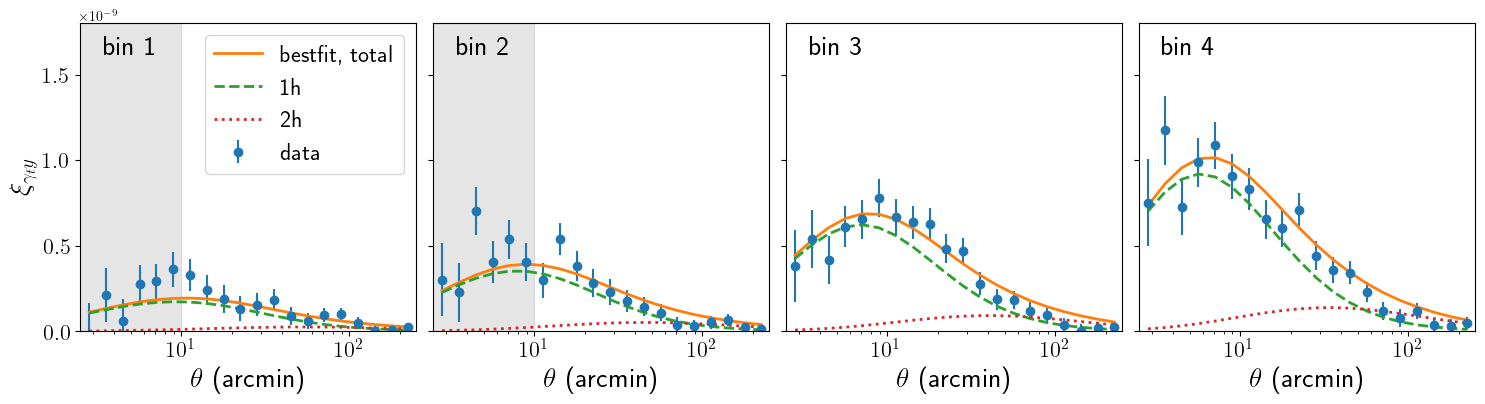

In [24]:
# make a four subplot figure:
fig, axes = pl.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji in range(4):
    ax = axes[ji]
    ax.errorbar(theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label='data', ls='', marker='o')
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_all[ji*20:(ji+1)*20], label='bestfit, total', lw=2)
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_1h_ym[:, ji], label='1h', ls='--', lw=2)
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_2h_ym[:, ji], label='2h', ls=':', lw=2)
    # ax.set_title(f'gty bin {ji+1}')
    if ji == 0:
        ax.legend(fontsize=17)
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_ylim(0, 1.8e-9)
    ax.set_xlabel(r'$\theta$ (arcmin)', fontsize=20)

    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=16)
    ax.set_xlim(2.5, 250)
    ax.text(0.07, 0.9, f'bin {ji+1}', transform=ax.transAxes, fontsize=20)
    if ji == 0:
        ax.set_ylabel(r'$\xi_{\gamma_t y}$', fontsize=20)

    if ji < 2:
        ax.axvspan(0, 10, color='gray', alpha=0.2)
    # ax.set_xlim(0, 20)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# fig.savefig(sdir + 'gty_dv_v12.pdf', bbox_inches='tight', dpi=300)
pl.show()









In [36]:
ldir = abs_path_results + '/DESxACT/chains_Feb/'
df = pk.load(open(ldir + 'mcmc_v13_maskPS_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))



In [37]:
# map_ind = 48724
map_ind = 89042
saved_bestfit = {}
for jk, key in enumerate(keys):
    print(key, samps[map_ind, jk])
    saved_bestfit[key] = samps[map_ind, jk]


A_IA 0.43079769265671697
Delta_z_bias_array_0 -0.005207044020970491
Delta_z_bias_array_1 -0.012303619110993827
Delta_z_bias_array_2 -0.011998994694951385
Delta_z_bias_array_3 0.0004852758697119064
Ob0 0.04243243203084305
Om0 0.3154273746441276
alpha_ky 1.084755396252362
alpha_nt 0.07213425551201519
eta_IA 4.04574163822295
h 0.6133402669370606
mu_beta 0.5779297967931791
mult_shear_bias_array_0 -0.0030867798432643602
mult_shear_bias_array_1 -0.020808461035490076
mult_shear_bias_array_2 -0.029793914425711072
mult_shear_bias_array_3 -0.04025126187760956
ns 0.9959408430065385
nu_theta_ej_M -0.2412023132918574
nu_theta_ej_z -1.7676013373441242
sigma8 0.8148020473735006
theta_ej_0 5.93445459684621
S8 0.8354898435630969


In [38]:
2+2# potential_energy -4916.635080802822
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
new_data = read_yaml(abs_path_params + '/DESxACT/params_v3.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)


# saved_bestift
from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])


analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)


for key in saved_bestfit.keys():
    if key in list(sim_params_dict.keys()):
        sim_params_dict[key] = float(saved_bestfit[key])
    if key in list(sim_params_dict['cosmo'].keys()):
        sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
        if key == 'h':
            sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
    if key in list(other_params_dict.keys()):
        other_params_dict[key] = float(saved_bestfit[key])
for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
    other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
    other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']


base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)


from godmax.base_class import get_vmapped_func, get_vmapped_func_warg, EmptyCallable
import interpax
import jax.scipy.integrate as jsi
from mcfitjax.transforms import Hankel

Bl_mat = (jnp.exp(-1. * Pkz_test.ell_array * (Pkz_test.ell_array + 1) * (Pkz_test.sig_beam ** 2) / 2.))[:, None]
def get_xi_pred(Pk_mat, isym, ismm_p, ismm_m):
    # Convert the 3D power spectra multipole space Pkz_ell:
    vmapped_func = get_vmapped_func_warg(Cls_test.get_P_lz, 2, 3)
    Pk_lz_mat = vmapped_func(jnp.arange(Pkz_test.nell), jnp.arange(Pkz_test.nz), Pk_mat).T    
    if isym:
        Pk_lz_mat = Pk_lz_mat * Bl_mat
    logPklz_2d_interp = interpax.Interpolator2D(jnp.log(Pkz_test.ell_array), Pkz_test.z_array, jnp.log(Pk_lz_mat), extrap=True)        
    
    def get_Cl_tot(jl, jb1, jb2, probe1, probe2): 
        # Handle the first probe condition
        def compute_prefac(probe, jb):
            conditions = [
                (probe == 0, (1. + Cls_test.mult_shear_bias_array[jb]) * (Cls_test.Wk_mat[jb] / (Cls_test.chi_array_for_Cls**2))),
                (probe == 3, Cls_test.Wy_array / (Cls_test.chi_array_for_Cls**2)),
            ]
            
            prefac = jnp.nan
            for condition, value in conditions:
                prefac = jnp.where(condition, value, prefac)
            return prefac
    
        # Compute prefactors for probe1 and probe2
        prefac_for_uk1 = compute_prefac(probe1, jb1)
        prefac_for_uk2 = compute_prefac(probe2, jb2)        
    
        Pk = jnp.exp(logPklz_2d_interp(jnp.log(Cls_test.ell_array[jl]), Cls_test.z_array_for_Cls))
        fx = prefac_for_uk1 * prefac_for_uk2  * (Cls_test.chi_array_for_Cls ** 2) * Cls_test.dchi_dz_array_for_Cls * Pk
        return jsi.trapezoid(fx, x=Cls_test.z_array_for_Cls)  
        
    
    if isym:
        vmapped_func = get_vmapped_func_warg(get_Cl_tot, 2, 5)
        Cl_mat = vmapped_func(jnp.arange(Cls_test.nell), jnp.arange(Cls_test.nbins), 0, 0, 3).T
        theta_out, xi_out = (Hankel(Cls_test.ell_array, nu=2, q=1.0, nx=Cls_test.nell, lowring=True)(Cl_mat, axis=0, extrap=False))
        theta_out_arcmin = theta_out * (180. / jnp.pi) * 60.
        gty_tot_mat = jnp.array(xi_out * (1 / (2 * jnp.pi)))
        
        def interp_gty_theta(jt, jb):
            gty_out = jnp.exp(jnp.interp(jnp.log(xis_test.angles_data_array[jt]), jnp.log(theta_out_arcmin), jnp.log(gty_tot_mat[:, jb])))
            return gty_out

        xi_out_mat = get_vmapped_func(interp_gty_theta, 2)(jnp.arange(xis_test.nt_out), jnp.arange(xis_test.nbins)).T
        
    
    else:
        vmapped_func = get_vmapped_func_warg(get_Cl_tot, 3, 5)
        Cl_mat = vmapped_func(jnp.arange(Cls_test.nell), jnp.arange(Cls_test.nbins), jnp.arange(Cls_test.nbins), 0, 0).T
        if ismm_p:
            theta_out, xi_out = (Hankel(xis_test.ell_array, nu=0, q=1.0, nx=xis_test.nell, lowring=True)(Cl_mat, axis=0, extrap=False))        
        if ismm_m:
            theta_out, xi_out = (Hankel(xis_test.ell_array, nu=4, q=1.0, nx=xis_test.nell, lowring=True)(Cl_mat, axis=0, extrap=False))        
        theta_out_arcmin = theta_out * (180. / jnp.pi) * 60.
        xi_tot_mat = jnp.array(xi_out * (1 / (2 * jnp.pi)))
        def interp_xipm_theta(jb1, jb2):
            xi_out = jnp.exp(jnp.interp(jnp.log(xis_test.angles_data_array), jnp.log(theta_out_arcmin), jnp.log(xi_tot_mat[:, jb1,jb2])))
            return xi_out
        xi_out_mat = get_vmapped_func(interp_xipm_theta, 2)(jnp.arange(xis_test.nbins), jnp.arange(xis_test.nbins)).T

    return xi_out_mat
    

gty_1h_ym = get_xi_pred(Pkz_test.Pym_1h_kz_mat, 1, 0, 0)
gty_2h_ym = get_xi_pred(Pkz_test.Pym_2h_kz_mat, 1, 0, 0)

deproj_to_true_y_file = {
    'None': 'ilc_SZ_yy',
    'cib_1p0': 'ilc_SZ_deproj_cib_1.0_10.7_yy',
    'cib_1p2': 'ilc_SZ_deproj_cib_1.2_10.7_yy',
    'cib_1p4': 'ilc_SZ_deproj_cib_1.4_10.7_yy',
    'cib_1p6': 'ilc_SZ_deproj_cib_1.6_10.7_yy',
    'cib_1p7': 'ilc_SZ_deproj_cib_1.7_10.7_yy',
    'cib_1p8': 'ilc_SZ_deproj_cib_1.8_10.7_yy',
    'cib_2p0': 'ilc_SZ_deproj_cib_2.0_10.7_yy',
    'cib_1p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.0_10.7_yy',
    'cib_1p2_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.2_10.7_yy',
    'cib_1p4_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.4_10.7_yy',
    'cib_1p6_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy',
    'cib_1p7_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy',
    'cib_1p8_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.8_10.7_yy',
    'cib_2p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_2.0_10.7_yy',
}
deproj = 'cib_1p7_dBeta'
probe = 'all'
# save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
# save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v3/')
save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v4/')
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}_maskedPS_maskang_3_5sigma_thresh.pk', 'rb'))
df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}_maskedPS.pk', 'rb'))
cov_total = df_measure['cov_total']
xi_all = df_measure['xi_all']
theta_all = df_measure['theta_all']
bin1_all = df_measure['bin1_all']
bin2_all = df_measure['bin2_all']
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)

# save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}_maskedPS_maskang_3_5sigma_thresh.pk', 'rb'))
# cov_total = df_measure['cov_total']
# xi_all = df_measure['xi_all']
# theta_all = df_measure['theta_all']
# cov_total = jnp.array(cov_total)
# data_vec = jnp.array(xi_all)

df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate_newbins.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])
ang_vals = df_cs['xip'].data['ANG'][0:20]



cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)


gty_dv = data_vec[:80]
sig_gty_dv = np.sqrt(np.diag(cov_total))[:80]

xip_dv = data_vec[80:280]
sig_xip_dv = np.sqrt(np.diag(cov_total))[80:280]
bin1_xip_dv = df_cs['xip'].data['BIN1']
bin2_xip_dv = df_cs['xip'].data['BIN2']

xim_dv = data_vec[280:]
sig_xim_dv = np.sqrt(np.diag(cov_total))[280:]
bin1_xim_dv = df_cs['xim'].data['BIN1']
bin2_xim_dv = df_cs['xim'].data['BIN2']

if probe == 'xip_xim':
    cov_total = cov_total[80:, 80:]
    data_vec = data_vec[80:]
elif probe == 'gty':
    cov_total = cov_total[:80, :80]
    data_vec = data_vec[:80]

fname = abs_path_data + '/DESxACT/scale_cuts_xipm_y3_gty_fid.ini'
config = configobj.ConfigObj(fname)
sc_xipm = config['shear-shear']
sc_gty = config['shear-tsz']



def process_indices(num, bin1_vals, bin2_vals, angle_ranges, offset, probe, angle_type, do_scalecuts):
    indices, indrm = [], []
    for js in range(num):
        binv, thetav = divmod(js, 20)
        bin1, bin2 = (bin1_vals[binv] - 1, bin2_vals[binv] - 1) if angle_type != 'gty' else (None, None)
        if do_scalecuts:
            sc_min, sc_max = map(float, angle_ranges[binv].split())
        else:
            sc_min, sc_max = 1e-3, 999.0
        if sc_min < ang_vals[thetav] < sc_max:
            indices.append([int(thetav), int(bin1), int(bin2)] if bin1 is not None else [int(thetav), int(binv)])
        elif probe in [angle_type, 'all']:
            indrm.append(int(offset + js))
    return jnp.array(indices, dtype=jnp.int32), jnp.array(indrm, dtype=jnp.int32)

# Process gty indices
sc_ranges_gty = [sc_gty[f'angle_range_gty_{biny}_0'] for biny in biny_vals]
index_gty, indrm_gty = process_indices(80, None, None, sc_ranges_gty, 0, probe, 'gty', False)
len_ind_gty = len(index_gty)
# Process xip indices
sc_ranges_xip = [sc_xipm[f'angle_range_xip_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xip = 80 if probe in ['gty', 'all'] else 0
index_xip, indrm_xip = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xip, offset_xip, probe, 'xip_xim', False)
len_ind_xip = len(index_xip)
# Process xim indices
sc_ranges_xim = [sc_xipm[f'angle_range_xim_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xim = 280 if probe in ['gty', 'all'] else 200
index_xim, indrm_xim = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xim, offset_xim, probe, 'xip_xim', False)
len_ind_xim = len(index_xim)


def get_gty_from_index(index):
    index_val = index_gty[index]
    return xis_test.gty_out_mat[index_val[0], index_val[1]]

def get_xip_from_index(index):
    index_val = index_xip[index]
    return xis_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

def get_xim_from_index(index):
    index_val = index_xim[index]
    return xis_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

gty_all = vmap(get_gty_from_index)(jnp.arange(len_ind_gty))
xip_all = vmap(get_xip_from_index)(jnp.arange(len_ind_xip))
xim_all = vmap(get_xim_from_index)(jnp.arange(len_ind_xim))






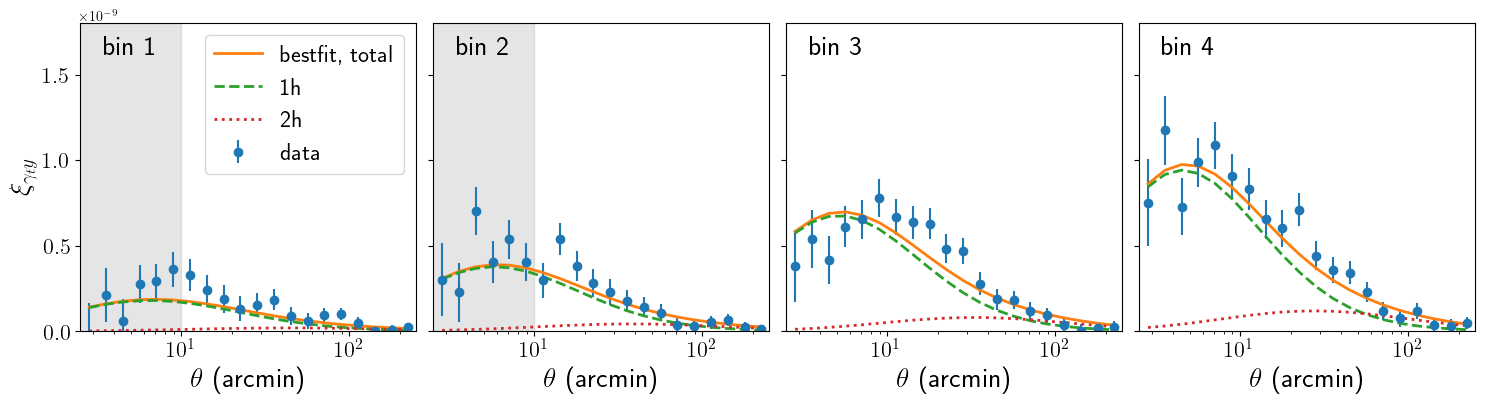

In [39]:
# make a four subplot figure:
fig, axes = pl.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji in range(4):
    ax = axes[ji]
    ax.errorbar(theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label='data', ls='', marker='o')
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_all[ji*20:(ji+1)*20], label='bestfit, total', lw=2)
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_1h_ym[:, ji], label='1h', ls='--', lw=2)
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_2h_ym[:, ji], label='2h', ls=':', lw=2)
    # ax.set_title(f'gty bin {ji+1}')
    if ji == 0:
        ax.legend(fontsize=17)
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_ylim(0, 1.8e-9)
    ax.set_xlabel(r'$\theta$ (arcmin)', fontsize=20)

    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=16)
    ax.set_xlim(2.5, 250)
    ax.text(0.07, 0.9, f'bin {ji+1}', transform=ax.transAxes, fontsize=20)
    if ji == 0:
        ax.set_ylabel(r'$\xi_{\gamma_t y}$', fontsize=20)

    if ji < 2:
        ax.axvspan(0, 10, color='gray', alpha=0.2)
    # ax.set_xlim(0, 20)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# fig.savefig(sdir + 'gty_dv_v12.pdf', bbox_inches='tight', dpi=300)
pl.show()







In [40]:
xip_1h_ym = get_xi_pred(Pkz_test.Pmm_dmb_1h_kz_mat, 0, 1, 0)
xip_2h_ym = get_xi_pred(Pkz_test.Pmm_dmb_2h_kz_mat, 0, 1, 0)
xip_hf_ym = get_xi_pred(Pkz_test.phfit_kz_mat, 0, 1, 0)


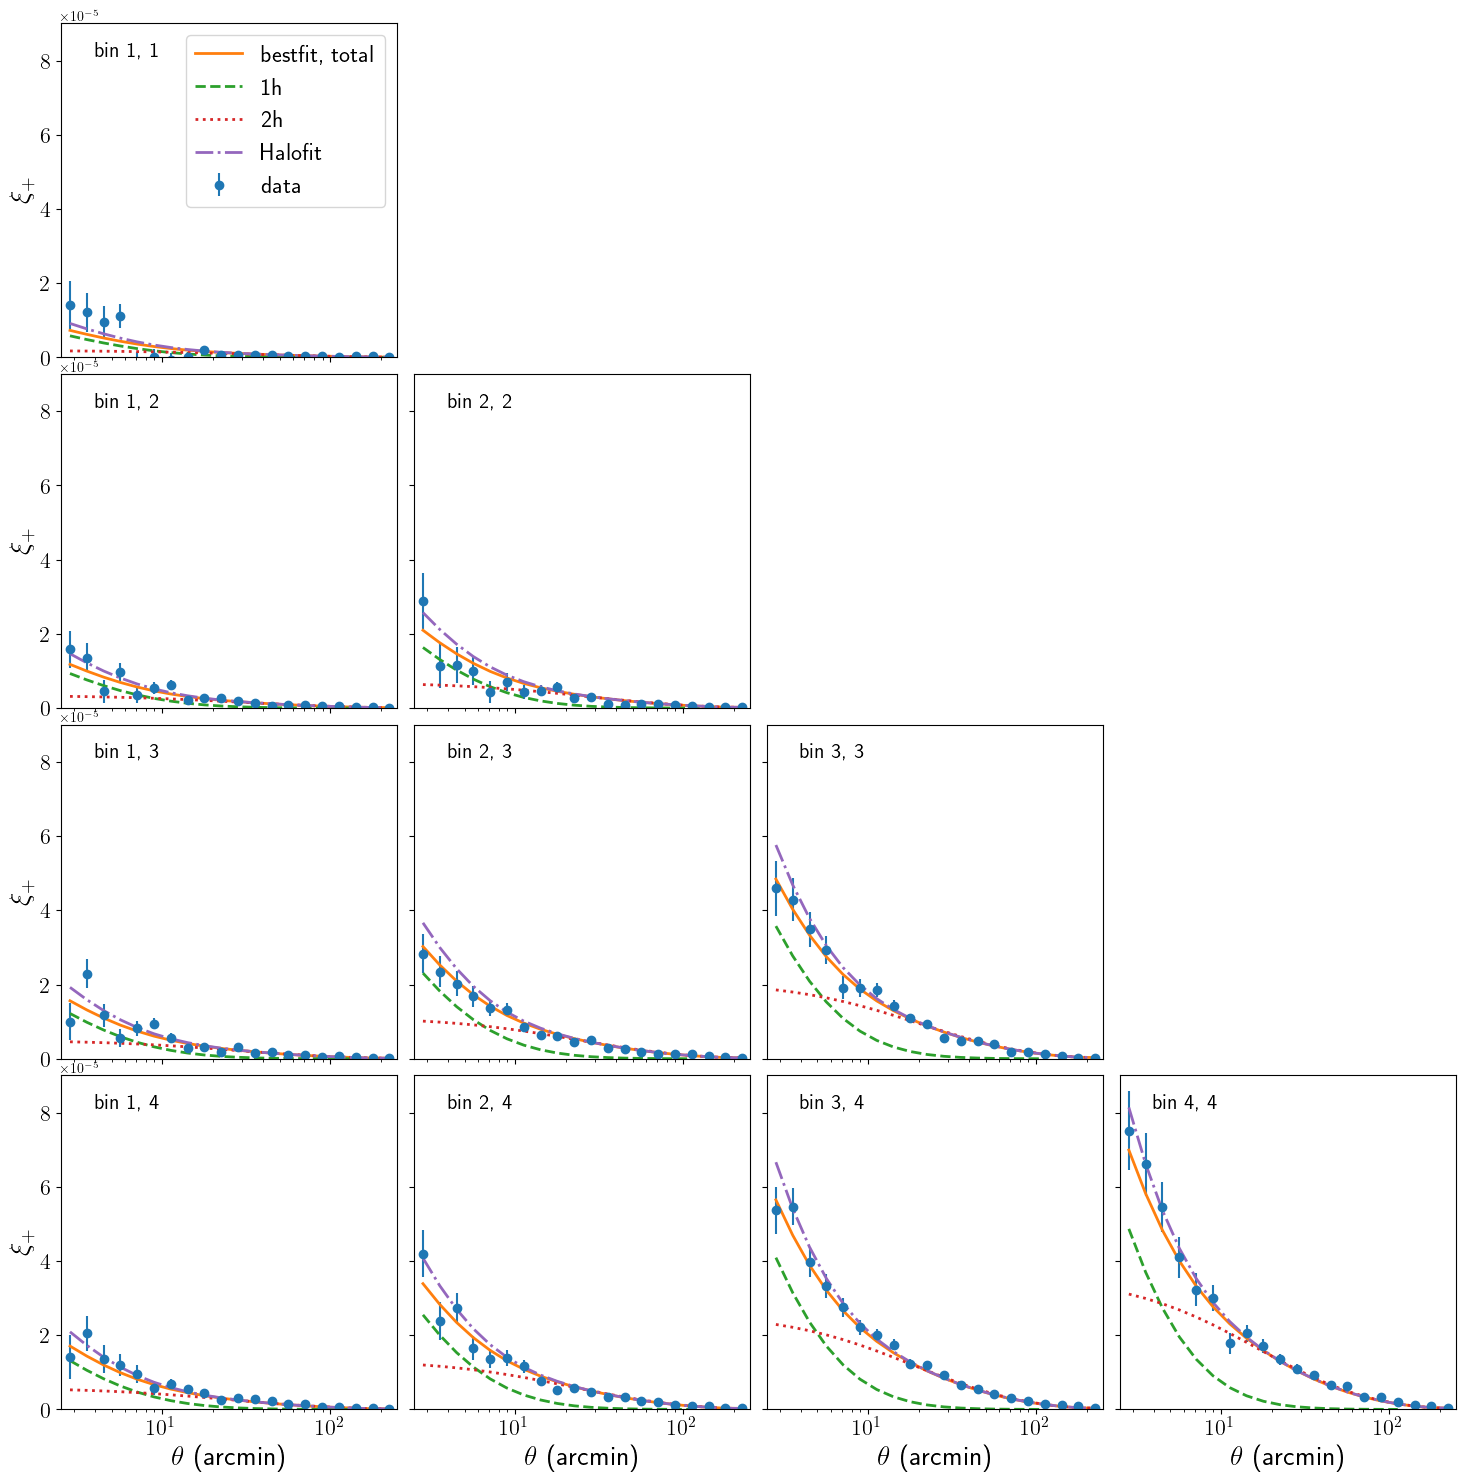

In [41]:
# make a four subplot figure:
theta_xip = theta_all[80:280]
theta_xim = theta_all[280:]
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xip_dv == ji1+1) & (bin2_xip_dv == ji2+1))[0]
            ax.errorbar(theta_xip[indsel], xip_dv[indsel], sig_xip_dv[indsel], label='data', ls='', marker='o')
            ax.plot(theta_xip[indsel], xip_all[indsel], label='bestfit, total', lw=2)
            ax.plot(theta_xip[indsel], xip_1h_ym[:,ji1, ji2], label='1h', lw=2, ls='--')
            ax.plot(theta_xip[indsel], xip_2h_ym[:,ji1, ji2], label='2h', lw=2, ls=':')
            ax.plot(theta_xip[indsel], xip_hf_ym[:,ji1, ji2], label='Halofit', lw=2, ls='-.')
            # ax.set_title(f'gty bin {ji+1}')
            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0, 9e-5)
            ax.set_xlim(2.5, 250)
            ax.text(0.1, 0.9, f'bin {ji1+1}, {ji2+1}', transform=ax.transAxes, fontsize=15)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$ (arcmin)', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$\xi_{+}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
# sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# fig.savefig(sdir + 'xip_dv_v10.pdf', bbox_inches='tight', dpi=300)
# fig.savefig(sdir + 'xip_dv_v12.pdf', bbox_inches='tight', dpi=300)
pl.show()



In [42]:
xim_1h_ym = get_xi_pred(Pkz_test.Pmm_dmb_1h_kz_mat, 0, 0, 1)
xim_2h_ym = get_xi_pred(Pkz_test.Pmm_dmb_2h_kz_mat, 0, 0, 1)
xim_hf_ym = get_xi_pred(Pkz_test.phfit_kz_mat, 0, 0, 1)



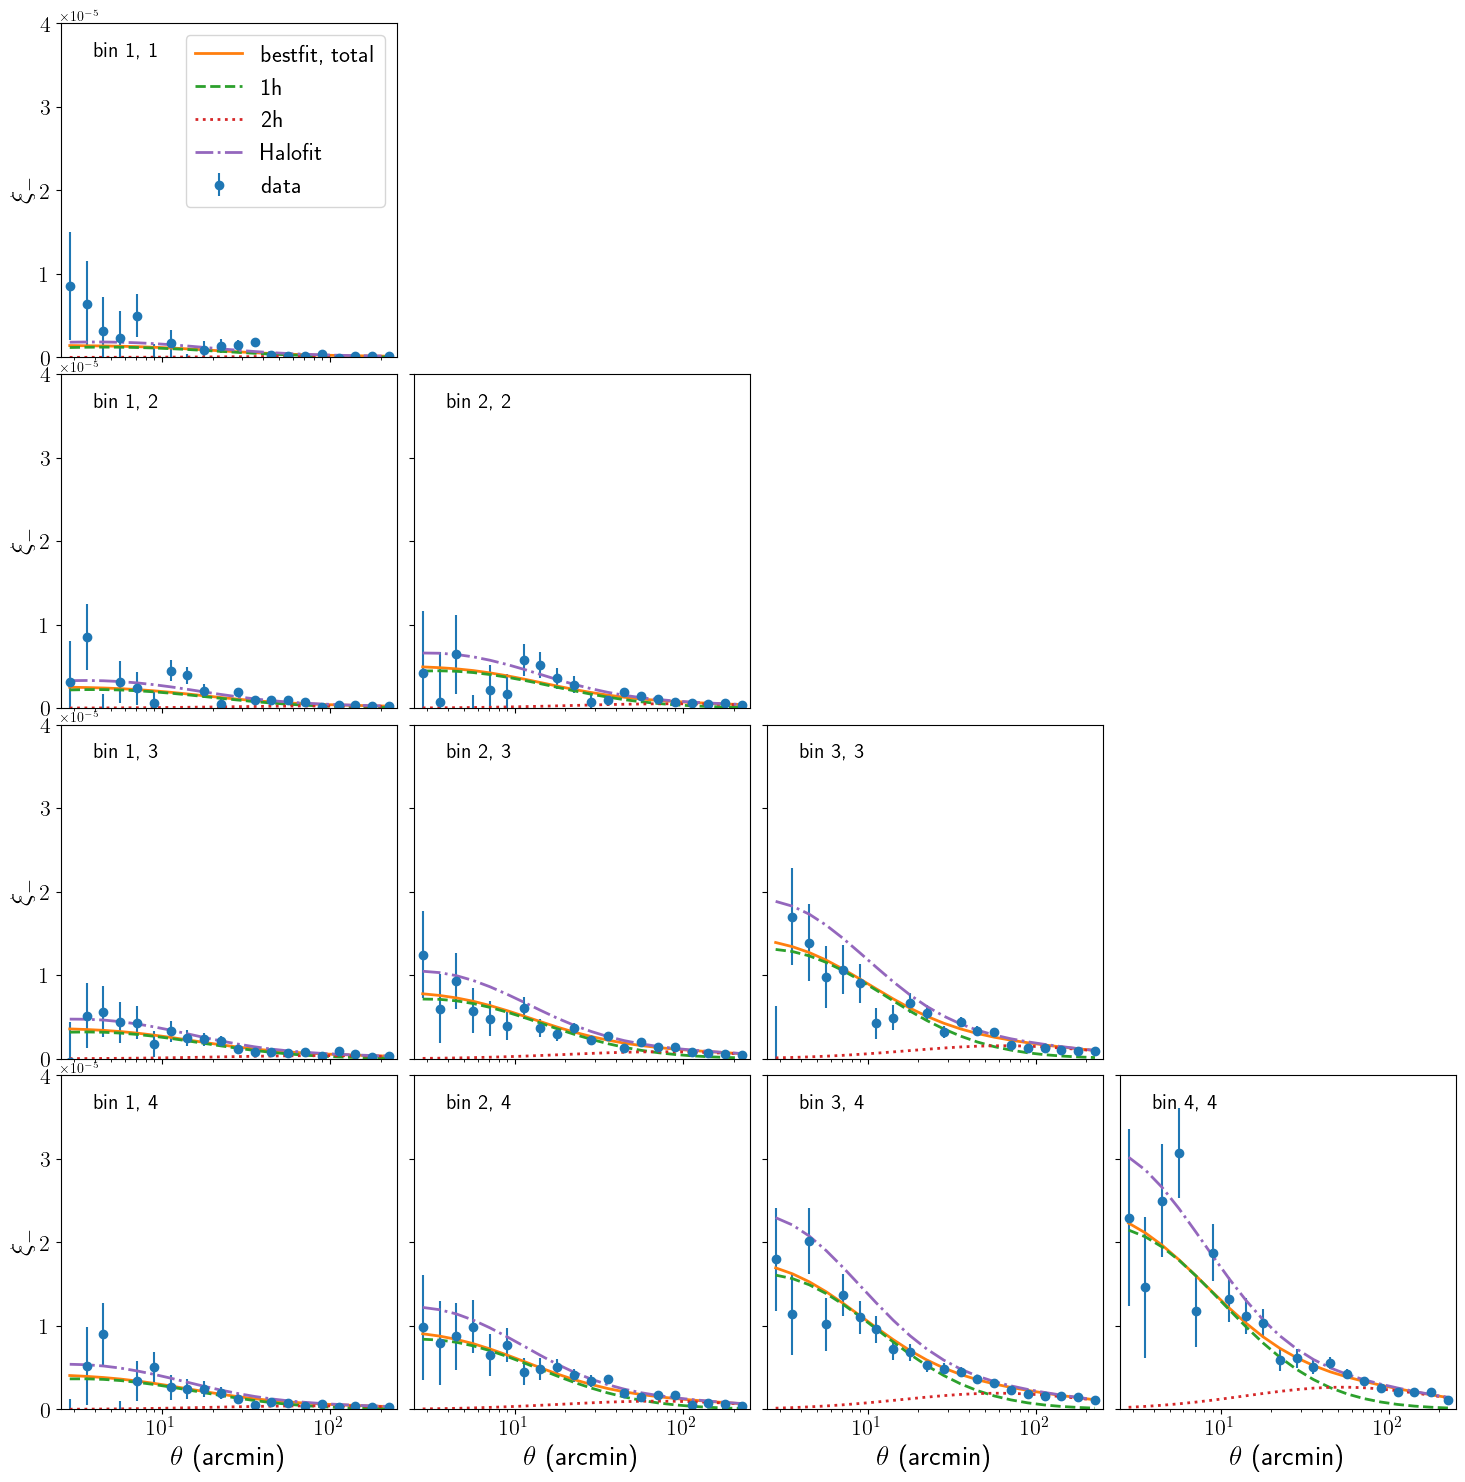

In [43]:
# make a four subplot figure:
theta_xip = theta_all[80:280]
theta_xim = theta_all[280:]
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xim_dv == ji1+1) & (bin2_xim_dv == ji2+1))[0]
            ax.errorbar(theta_xim[indsel], xim_dv[indsel], sig_xim_dv[indsel], label='data', ls='', marker='o')
            ax.plot(theta_xim[indsel], xim_all[indsel], label='bestfit, total', lw=2)
            ax.plot(theta_xim[indsel], xim_1h_ym[:,ji1, ji2], label='1h', lw=2, ls='--')
            ax.plot(theta_xim[indsel], xim_2h_ym[:,ji1, ji2], label='2h', lw=2, ls=':')
            ax.plot(theta_xim[indsel], xim_hf_ym[:,ji1, ji2], label='Halofit', lw=2, ls='-.')
            # ax.set_title(f'gty bin {ji+1}')
            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0, 4e-5)
            ax.set_xlim(2.5, 250)
            ax.text(0.1, 0.9, f'bin {ji1+1}, {ji2+1}', transform=ax.transAxes, fontsize=15)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$ (arcmin)', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$\xi_{-}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# pl.yscale('log')
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xim_dv.png', bbox_inches='tight', dpi=300)
# sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# fig.savefig(sdir + 'xim_dv_v10.pdf', bbox_inches='tight', dpi=300)
# fig.savefig(sdir + 'xim_dv_v12.pdf', bbox_inches='tight', dpi=300)
pl.show()






In [14]:
samps, keys = get_samps(ldir + f'mcmc_v13_maskPS_probe_{probe}_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')


12
(208000, 22) (52, 4000, 22)


In [17]:
from tqdm import tqdm
from colossus.cosmology import cosmology as cosmology_colossus
from colossus.halo import mass_defs
from colossus.halo import concentration
from scipy.interpolate import interp1d
import jax_cosmo.background as bkgrd
# ind_post = keys.index('potential_energy')
# post = -1.* samps[:,ind_post]

# map_ind = np.where(post == post.max())[0][0]

fb_norm_all_samp = []

# for map_ind in tqdm(indsel):
# for map_ind in [89042]:
for map_ind in [26641]:
# for map_ind in tqdm(indsel[:1]):    
    saved_bestfit = {}
    for jk, key in enumerate(keys):
        # print(key, samps[map_ind, jk])
        saved_bestfit[key] = samps[map_ind, jk]
    
    # potential_energy -4916.635080802822
    import yaml
    import pathlib
    curr_path = pathlib.Path().absolute()
    abs_path_data = os.path.abspath(curr_path / "../../data/") 
    abs_path_src = os.path.abspath(curr_path / "../../src/") 
    abs_path_results = os.path.abspath(curr_path / "../../results/") 
    abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
    
    from deepmerge import always_merger
    def read_yaml(file_path):
        with open(file_path, 'r') as file:
            data = yaml.safe_load(file)
        return data
    
    def generate_dicts(data):
        sim_params_dict = data.get('sim_params', {})
        halo_params_dict = data.get('halo_params', {})
        analysis_dict = data.get('analysis', {})
        other_params_dict = data.get('other_params', {})
        return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict
    
    default_data = read_yaml(abs_path_params + '/params_default.yaml')
    new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
    # new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
    merged_data = always_merger.merge(default_data, new_data)
    
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)
    
    
    # saved_bestift
    from astropy.io import fits
    df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
    z_array = df['nz_source'].data['Z_MID']
    nz_info_dict = {}
    nz_info_dict['z_array_source'] = z_array
    nz_info_dict['nbins'] = 4
    for ji in range(nz_info_dict['nbins']):
        nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
    analysis_dict['nz_source_info_dict'] = nz_info_dict
    other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    
    
    analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]
    
    lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
    l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
    dl_array = l_array_all[1:] - l_array_all[:-1]
    l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
    halo_params_dict['ell_array'] = jnp.array(l_array_survey)
    analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
    analysis_dict['dl_array_survey'] = jnp.array(dl_array)
    
    
    for key in saved_bestfit.keys():
        if key in list(sim_params_dict.keys()):
            sim_params_dict[key] = float(saved_bestfit[key])
        if key in list(sim_params_dict['cosmo'].keys()):
            sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
            if key == 'h':
                sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
        if key in list(other_params_dict.keys()):
            other_params_dict[key] = float(saved_bestfit[key])
    for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
        other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
    for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
        other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']
    
    cosmop = sim_params_dict['cosmo']
    params = {'w0':-1.0 ,'flat': True, 'H0': cosmop['H0'], 'Om0': cosmop['Om0'], 'Ob0': cosmop['Ob0'], 'sigma8':cosmop['sigma8'] ,'ns': cosmop['ns']}
    cosmology_colossus.addCosmology('myCosmo', params)
    cosmology_colossus.setCosmology('myCosmo')
    cosmo_colossus = cosmology_colossus.setCosmology('myCosmo')
    
    h = params['H0']/100.
    z = 0.0
    M500c_min_wh = 6e13*h
    M500c_max_wh = 2e14*h
    c500c_min_wh = concentration.concentration(M500c_min_wh, '500c', z, model = 'bhattacharya13')
    c500c_max_wh = concentration.concentration(M500c_max_wh, '500c', z, model = 'bhattacharya13')
    M200c_min_wh, _, _ = mass_defs.changeMassDefinition(M500c_min_wh, c500c_min_wh, z, '500c', '200c')
    M200c_max_wh, _, _ = mass_defs.changeMassDefinition(M500c_max_wh, c500c_max_wh, z, '500c', '200c')
    
    halo_params_dict['lg10_Mmin'] = np.log10(M200c_min_wh)
    halo_params_dict['lg10_Mmax'] = np.log10(M200c_max_wh)
    
    halo_params_dict['zmin'] = 0.001
    halo_params_dict['zmax'] = 0.01
    halo_params_dict['nz'] = 3

    halo_params_dict['nr'] = 32
    
    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    
    
    M200c_array = profiles_test.M_array
    conc_array = profiles_test.conc_Mz_mat[0,:]
    M500c_array, R500c_array, _ = mass_defs.changeMassDefinition(M200c_array, conc_array, z, '200c', '500c')
    R500c_array /= 1000.
    
    rho_baryon_mat = profiles_test.rho_gas_mat + profiles_test.rho_cga_mat + ((profiles_test.fstar_sat_mat/profiles_test.fclm_mat)[None,:,:])*profiles_test.rho_clm_mat
    rho_tot_mat = profiles_test.rho_dmb_mat
    rho_baryon_mat_z0 = rho_baryon_mat[:,0,:]
    rho_tot_mat_z0 = rho_tot_mat[:,0,:]
    
    fb_array = np.zeros(len(M500c_array))
    for jM in range(len(M500c_array)):
            r500_jM = R500c_array[jM]
            r_array_jM = np.logspace(-3, np.log10(r500_jM), 100)
            rho_baryon_jM = rho_baryon_mat_z0[:,jM]
            interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_baryon_jM), fill_value='extrapolate')
            rhob_jM = np.exp(interprho(np.log(r_array_jM)))
            rhob_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhob_jM, np.log(r_array_jM))
    
    
            rho_tot_jM = rho_tot_mat_z0[:,jM]
            interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_tot_jM), fill_value='extrapolate')
            rhotot_jM = np.exp(interprho(np.log(r_array_jM)))
            rhotot_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhotot_jM, np.log(r_array_jM))
    
            fb_array[jM] = rhob_int_jM/rhotot_int_jM
    
    fb_bar = np.trapezoid(fb_array * profiles_test.hmf_Mz_mat[0, :], x=np.log(profiles_test.M_array))/np.trapezoid(profiles_test.hmf_Mz_mat[0, :], x=np.log(profiles_test.M_array))
    fb_bar_norm = fb_bar/(cosmop['Ob0']/cosmop['Om0'])

    fb_norm_all_samp.append(fb_bar_norm)
    
    



In [18]:
# Cl_yy_all_samp.shape
fb_bar_norm




np.float64(0.33503755396926976)

(100.0, 6000.0)

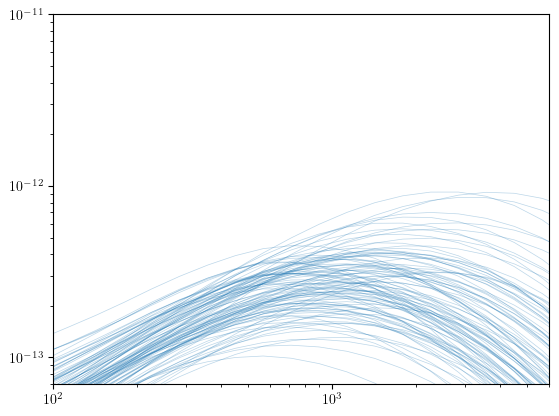

In [ ]:
# Cl_yy
fach = fac = ((base_test.ell_array)*(base_test.ell_array + 1) / (2 * np.pi))
pl.figure()
# pl.fill_between(base_test.ell_array, Dlyymin, Dlyymax, color='tab:blue', alpha=0.3, label='shear-2pt only')
for Cl_yy in Cl_yy_all_samp:
    pl.plot(base_test.ell_array, fach*Cl_yy, color='tab:blue', alpha=0.3, lw=0.5)

pl.xscale('log')
pl.yscale('log')
pl.ylim(7e-14, 1e-11)
pl.xlim(1e2, 6e3)




(100.0, 6000.0)

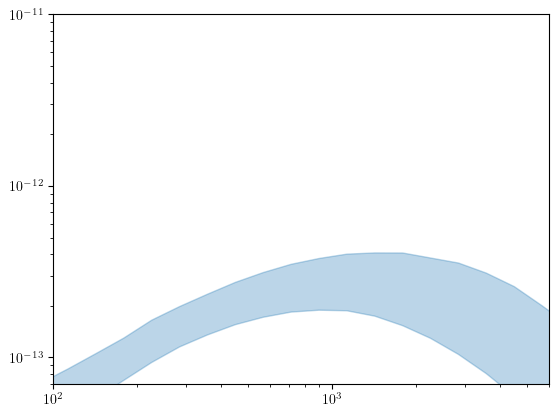

In [65]:
# Cl_yy
fach = fac = ((base_test.ell_array)*(base_test.ell_array + 1) / (2 * np.pi))
pl.figure()
pl.fill_between(base_test.ell_array, Dlyymin, Dlyymax, color='tab:blue', alpha=0.3, label='shear-2pt only')
# for Cl_yy in Cl_yy_all_samp:
#     pl.plot(base_test.ell_array, fach*Cl_yy, color='tab:blue', alpha=0.3, lw=0.5)

pl.xscale('log')
pl.yscale('log')
pl.ylim(7e-14, 1e-11)
pl.xlim(1e2, 6e3)




In [ ]:
import numpy as np
from astropy import constants as const
from astropy import units as u

def get_Tcmb_K():
    Tcmb = 2.7255
    return Tcmb

def tsz_freq(nu):
    #Input frequency in GHz, output conversion from y to \Delta T/T_CMB
    #nu in GHz
    #See carlstrom paper: https://ned.ipac.caltech.edu/level5/Sept05/Carlstrom/Carlstrom2.html
    T_cmb = get_Tcmb_K()*u.K
    x = (const.h*nu*(1.0e9*1./u.s)/(const.k_B*T_cmb)).to('').value
    f_x = x*((np.exp(x) + 1.)/(np.exp(x) - 1.)) - 4.
    return f_x

fac = (1e-12)/(((get_Tcmb_K())*tsz_freq(150))**2)

fnameDl_yy_planck = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/bolliet_18_cl_yy_mean.txt')
ell = fnameDl_yy_planck[:,0]
Dl_yy_planck = fnameDl_yy_planck[:,1] * 1e-12

fnameDl_yy_planck = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/bolliet_18_cl_yy_meanp1sig.txt')
err_Dlyy_planck = (fnameDl_yy_planck[:,1] * 1e-12 - Dl_yy_planck)


act_Dl_ratio = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/ACT_DR6_Dlyy_ratio_3000.txt')
ell_act_Dl_ratio = act_Dl_ratio[:,0]
Dl_ratio_act = act_Dl_ratio[:,1]


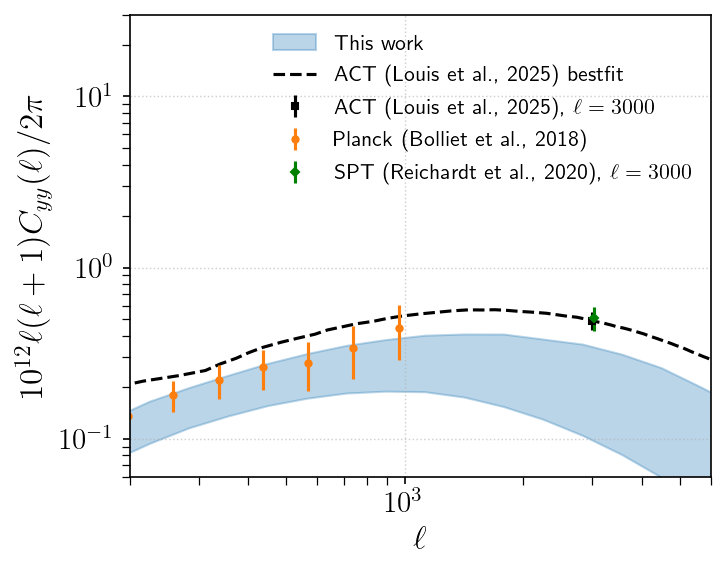

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4), dpi=150)

# Fill region with transparency
# plt.fill_between(M_array, Ymin, Ymax, alpha=0.3, color='tab:blue', label='This Work')
plt.fill_between(base_test.ell_array, 1e12*Dlyymin, 1e12*Dlyymax, color='tab:blue', alpha=0.3, label='This work')
# plt.fill_between(M_array, Ymin_2sigma, Ymax_2sigma, alpha=0.2, color='tab:blue')

# Plot main curve with improved styling
vljv,vljvp, vljvn = 3.3*fac,(3.3+0.4)*fac,(3.3-0.4)*fac
plt.errorbar(np.array([3000.]),1e12*np.array([vljv]),yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='s',ms='3',color='black',label=r'ACT (Louis et al., 2025), $\ell=3000$')
plt.plot(ell_act_Dl_ratio, 1e12*Dl_ratio_act*3.3*fac, ls='--', color='black', label='ACT (Louis et al., 2025) bestfit')
plt.errorbar(ell, 1e12*Dl_yy_planck, yerr=1e12*err_Dlyy_planck, ls='', marker='o', ms='3', color='tab:orange', label='Planck (Bolliet et al., 2018)')
vljv,vljvp, vljvn = 3.42*fac,(3.42+0.54)*fac,(3.42-0.54)*fac
plt.errorbar([3024],[1e12*vljv],yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='D',ms='3',color='green',label=r'SPT (Reichardt et al., 2020), $\ell=3000$')



# Log scales for better visualization
plt.xscale('log')
plt.yscale('log')

# Axis labels with LaTeX-style formatting
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$10^{12} \ell (\ell + 1) C_{yy}(\ell)/2\pi$', fontsize=16)

# Improved axis limits
plt.ylim(1e12*6e-14, 1e12*3e-11)
plt.xlim(2e2, 6e3)

# Improved legend with frame and better positioning
plt.legend(fontsize=10.5, frameon=False, loc='best')

# Better tick formatting for readability
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

# Grid with transparency for better visualization
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality
# sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# plt.savefig(sdir + 'Dl_yy_infer.pdf', bbox_inches='tight', dpi=300) 

plt.show()



In [72]:
import numpy as np
from astropy import constants as const
from astropy import units as u

def get_Tcmb_K():
    Tcmb = 2.7255
    return Tcmb

def tsz_freq(nu):
    #Input frequency in GHz, output conversion from y to \Delta T/T_CMB
    #nu in GHz
    #See carlstrom paper: https://ned.ipac.caltech.edu/level5/Sept05/Carlstrom/Carlstrom2.html
    T_cmb = get_Tcmb_K()*u.K
    x = (const.h*nu*(1.0e9*1./u.s)/(const.k_B*T_cmb)).to('').value
    f_x = x*((np.exp(x) + 1.)/(np.exp(x) - 1.)) - 4.
    return f_x

fac = (1e-12)/(((get_Tcmb_K())*tsz_freq(150))**2)

fnameDl_yy_planck = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/bolliet_18_cl_yy_mean.txt')
ell = fnameDl_yy_planck[:,0]
Dl_yy_planck = fnameDl_yy_planck[:,1] * 1e-12

fnameDl_yy_planck = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/bolliet_18_cl_yy_meanp1sig.txt')
err_Dlyy_planck = (fnameDl_yy_planck[:,1] * 1e-12 - Dl_yy_planck)


act_Dl_ratio = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/ACT_DR6_Dlyy_ratio_3000.txt')
ell_act_Dl_ratio = act_Dl_ratio[:,0]
Dl_ratio_act = act_Dl_ratio[:,1]



In [ ]:
# 1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T



Array(2837.08209465, dtype=float64)

4 0.4803781334662753 0.506583372163884
33 0.4661214731108051 0.506583372163884
35 0.5277482801320418 0.506583372163884
42 0.5543919847103694 0.506583372163884
87 0.5187367273681333 0.506583372163884


(100.0, 6000.0)

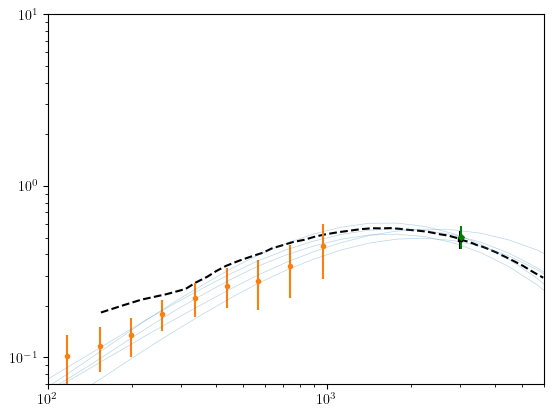

In [90]:
# Cl_yy
fach = 1e12*((base_test.ell_array)*(base_test.ell_array + 1) / (2 * np.pi))
pl.figure()
# pl.fill_between(base_test.ell_array, Dlyymin, Dlyymax, color='tab:blue', alpha=0.3, label='shear-2pt only')

fac = (1e-12)/(((get_Tcmb_K())*tsz_freq(150))**2)
vljv,vljvp, vljvn = 3.3*fac,(3.3+0.4)*fac,(3.3-0.4)*fac
pl.errorbar(np.array([3000.]),1e12*np.array([vljv]),yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='s',ms='3',color='black',label=r'ACT (Louis et al., 2025), $\ell=3000$')
pl.plot(ell_act_Dl_ratio, 1e12*Dl_ratio_act*3.3*fac, ls='--', color='black', label='ACT (Louis et al., 2025) bestfit')
pl.errorbar(ell, 1e12*Dl_yy_planck, yerr=1e12*err_Dlyy_planck, ls='', marker='o', ms='3', color='tab:orange', label='Planck (Bolliet et al., 2018)')
vljv,vljvp, vljvn = 3.42*fac,(3.42+0.54)*fac,(3.42-0.54)*fac
pl.errorbar([3024],[1e12*vljv],yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='D',ms='3',color='green',label=r'SPT (Reichardt et al., 2020), $\ell=3000$')

for jy, Cl_yy in enumerate(Cl_yy_all_samp):
    # pl.plot(base_test.ell_array, fach*Cl_yy, color='tab:blue', alpha=0.3, lw=0.5)
    if np.abs((fach*Cl_yy)[np.argmin(np.abs(base_test.ell_array - 3000))] - 1e12*3.42*fac)/(1e12*3.42*fac) < 0.1:
        print(jy, (fach*Cl_yy)[np.argmin(np.abs(base_test.ell_array - 3000))], 1e12*3.42*fac)
        pl.plot(base_test.ell_array, fach*Cl_yy, color='tab:blue', alpha=0.3, lw=0.5)
        # print(np.abs((fach*Cl_yy)[np.argmin(np.abs(base_test.ell_array - 3000))] - 1e12*3.42*fac)/1e12*3.42*fac)
        # print(jy)
    


pl.xscale('log')
pl.yscale('log')
pl.ylim(7e-14*1e12, 1e-11*1e12)
pl.xlim(1e2, 6e3)




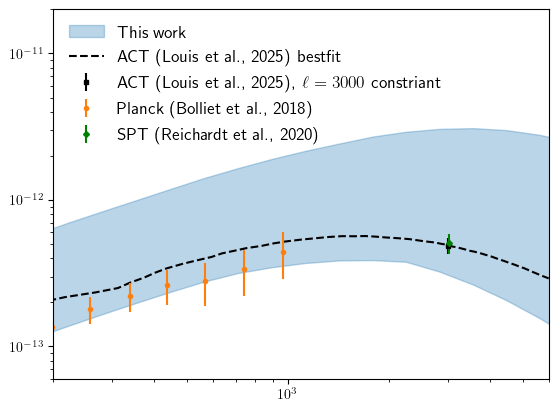

In [30]:
# Cl_yy
# fach = fac = ((base_test.ell_array)*(base_test.ell_array + 1) / (2 * np.pi))
pl.figure()
pl.fill_between(base_test.ell_array, Dlyymin, Dlyymax, color='tab:blue', alpha=0.3, label='This work')


# for Cl_yy in Cl_yy_all_samp:
#     pl.plot(base_test.ell_array, fach*Cl_yy, color='tab:blue', alpha=0.3, lw=0.5)

# vljv,vljvp, vljvn = 5.29*fac,(5.29+0.66)*fac,(5.29-0.66)*fac
# pl.errorbar(np.array([2928.3]),np.array([vljv]),yerr=np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='s',ms='3',color='blue',label='ACT (Choi et al., 2020)')


vljv,vljvp, vljvn = 3.3*fac,(3.3+0.4)*fac,(3.3-0.4)*fac
pl.errorbar(np.array([3000.]),np.array([vljv]),yerr=np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='s',ms='3',color='black',label=r'ACT (Louis et al., 2025), $\ell=3000$ constriant')

pl.plot(ell_act_Dl_ratio, Dl_ratio_act*3.3*fac, ls='--', color='black', label='ACT (Louis et al., 2025) bestfit')


pl.errorbar(ell, Dl_yy_planck, yerr=err_Dlyy_planck, ls='', marker='o', ms='3', color='tab:orange', label='Planck (Bolliet et al., 2018)')


# pl.plot(2928.3, vljv, ls='', marker='s', ms='8', color='blue', label='ACT (Choi et al., 2020)')

vljv,vljvp, vljvn = 3.42*fac,(3.42+0.54)*fac,(3.42-0.54)*fac
pl.errorbar([3024],[vljv],yerr=np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='D',ms='3',color='green',label='SPT (Reichardt et al., 2020)')

pl.xscale('log')
pl.yscale('log')
pl.ylim(6e-14, 2e-11)
pl.xlim(2e2, 6e3)
pl.legend(frameon=False, fontsize=12.5, loc='upper left')




In [88]:
# np.array([[vljv-vljvn,vljvp - vljv]]).T[...,0].shape
vljv

Array([1.16913068e+02, 1.82195007e+02, 2.84857311e+02, 4.46555690e+02,
       7.01558321e+02, 1.10410887e+03, 1.74009245e+03, 2.74552048e+03,
       4.33582133e+03, 6.85225582e+03, 1.08354717e+04, 1.71420681e+04,
       2.71293239e+04, 4.29479537e+04, 6.80060719e+04, 1.07704499e+05,
       1.70602106e+05, 2.70262715e+05, 4.28182184e+05, 6.78427450e+05,
       1.07498883e+06, 1.70343251e+06, 2.69936836e+06, 4.27771927e+06,
       6.77910968e+06, 1.07433862e+07, 1.70261394e+07, 2.69833785e+07,
       4.27642194e+07, 6.77747645e+07, 1.07413301e+08, 1.70235510e+08,
       2.69801199e+08, 4.27601171e+08, 6.77696001e+08, 1.07406799e+09,
       1.70227325e+09], dtype=float64)